# Seed Sweep Analysis: ifBO Greedy vs. Random Candidate Selection

Compares two ifBO candidate-selection strategies from
`sample-results/seeded/` (produced by `scripts/run_seed_sweep.py`, mirrored
from `seeded_runs_results/amazon/*/history.log.jsonl`):

- **ifBO (greedy)** — `ifbo_use_random_selection=False`,
  `ifbo_greedy_candidate_selection=True`. The acquisition function always
  proposes the candidate the FT-PFN surrogate ranks best.
- **ifBO (random selection)** — `ifbo_use_random_selection=True`. An
  ablation: candidates are drawn uniformly at random instead of by
  acquisition ranking (see `automl/core/optimizers/ifbo/optimizer.py`'s
  `_select_next_candidate`).

Each variant was run on the `amazon` dataset (`sequence-dl` approach) with
6 matched seeds: 12, 24, 36, 78, 90, 238 — the same seed run under both
variants, so comparisons below are paired per seed.

Each `sample-results/seeded/<variant>-seed<seed>.jsonl` file is a
`history.log.jsonl`-style trial log: one JSON object per completed trial
with its sampled `config`, `budget` (epochs trained), `val_error`,
`timestamp`, and per-epoch `epoch_history`.


In [1]:
import json
import math
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

RESULTS_DIR = Path("seeded")

VARIANTS = {
    "ifbo-greedy": "ifBO (greedy)",
    "ifbo-random": "ifBO (random selection)",
}

# Fixed categorical color per variant (entity), used unchanged across every
# chart below -- never re-cycled or reassigned per figure.
COLORS = {
    "ifbo-greedy": "#2a78d6",  # blue
    "ifbo-random": "#eda100",  # yellow
}

SEEDS = [12, 24, 36, 78, 90, 238]

GRID_NCOLS = 3
GRID_NROWS = math.ceil(len(SEEDS) / GRID_NCOLS)


def seed_grid(**subplots_kwargs):
    fig, axes = plt.subplots(GRID_NROWS, GRID_NCOLS, **subplots_kwargs)
    axes_flat = np.atleast_1d(axes).flatten()
    for ax in axes_flat[len(SEEDS) :]:
        ax.set_visible(False)
    return fig, axes_flat[: len(SEEDS)]


## Load trial histories

Every `ifbo-random-seed*.jsonl` file contains each `trialNo` **twice**: the
sweep's `python -m automl` process was invoked a second time for that
(variant, seed) cell, re-sampling the identical trial sequence (same
optimizer seed => same RNG draws) on top of the first run's config
checkpoints. Most of the second pass's `execution_time` values are ~0s
(instant checkpoint-cache hits, per `train_single_configuration` in
`automl/core/optimizers/base_optimizer.py`), confirming it's a redundant
replay rather than new search progress -- so we keep only the
chronologically first occurrence of each `trialNo` below. This does not
affect `ifbo-greedy-seed*.jsonl`, which has no duplicate `trialNo`s.


In [2]:
TIMESTAMP_FMT = "%Y%m%d_%H%M%S,%f"


def load_trials(path: Path) -> list[dict]:
    trials = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                trials.append(json.loads(line))
    return trials


def parse_stem(stem: str) -> tuple[str, int]:
    for variant_key in VARIANTS:
        prefix = variant_key + "-seed"
        if stem.startswith(prefix):
            return variant_key, int(stem[len(prefix) :])
    raise ValueError(f"Could not parse variant/seed from stem {stem!r}")


raw_trials: dict[tuple[str, int], list[dict]] = {}
rows = []

for path in sorted(RESULTS_DIR.glob("*.jsonl")):
    variant_key, seed = parse_stem(path.stem)
    trials = load_trials(path)
    trials.sort(key=lambda t: datetime.strptime(t["timestamp"], TIMESTAMP_FMT))

    n_raw = len(trials)
    seen_trial_nos: set[int] = set()
    deduped = []
    for t in trials:
        if t["trialNo"] not in seen_trial_nos:
            seen_trial_nos.add(t["trialNo"])
            deduped.append(t)
    trials = deduped
    if n_raw != len(trials):
        print(f"{path.name}: dropped {n_raw - len(trials)} duplicate-trialNo replay rows")

    raw_trials[(variant_key, seed)] = trials

    t0 = datetime.strptime(trials[0]["timestamp"], TIMESTAMP_FMT)
    running_best = float("inf")
    for t in trials:
        ts = datetime.strptime(t["timestamp"], TIMESTAMP_FMT)
        running_best = min(running_best, t["val_error"])
        rows.append(
            {
                "variant": variant_key,
                "seed": seed,
                "trialNo": t["trialNo"],
                "budget": t["budget"],
                "execution_time": t["execution_time"],
                "wallclock_s": (ts - t0).total_seconds(),
                "val_error": t["val_error"],
                "val_accuracy": 1.0 - t["val_error"],
                "best_val_accuracy_so_far": 1.0 - running_best,
            }
        )

trials_df = pd.DataFrame(rows)
trials_df["variant_label"] = trials_df["variant"].map(VARIANTS)
trials_df.head()


ifbo-random-seed12.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed238.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed24.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed36.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed78.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed90.jsonl: dropped 15 duplicate-trialNo replay rows


,variant,seed,trialNo,budget,execution_time,wallclock_s,val_error,val_accuracy,best_val_accuracy_so_far,variant_label
0,ifbo-greedy,12,1,3.0,100.317068,0.000000,0.2320,0.7680,0.7680,ifBO (greedy)
1,ifbo-greedy,12,2,3.0,138.230444,140.773663,0.2620,0.7380,0.7680,ifBO (greedy)
2,ifbo-greedy,12,3,3.0,198.855951,342.376841,0.2620,0.7380,0.7680,ifBO (greedy)
3,ifbo-greedy,12,4,3.0,69.525461,413.185156,0.2620,0.7380,0.7680,ifBO (greedy)
4,ifbo-greedy,12,5,3.0,291.944155,706.714649,0.2235,0.7765,0.7765,ifBO (greedy)


## 1. Best validation accuracy vs. trial number, per seed

Faint dots are individual trials; the step line is the running best-so-far
incumbent within that seed's run. ifBO (greedy) was configured for 20
trials and ifBO (random selection) for 15 in this sweep, so the greedy
lines extend further right.


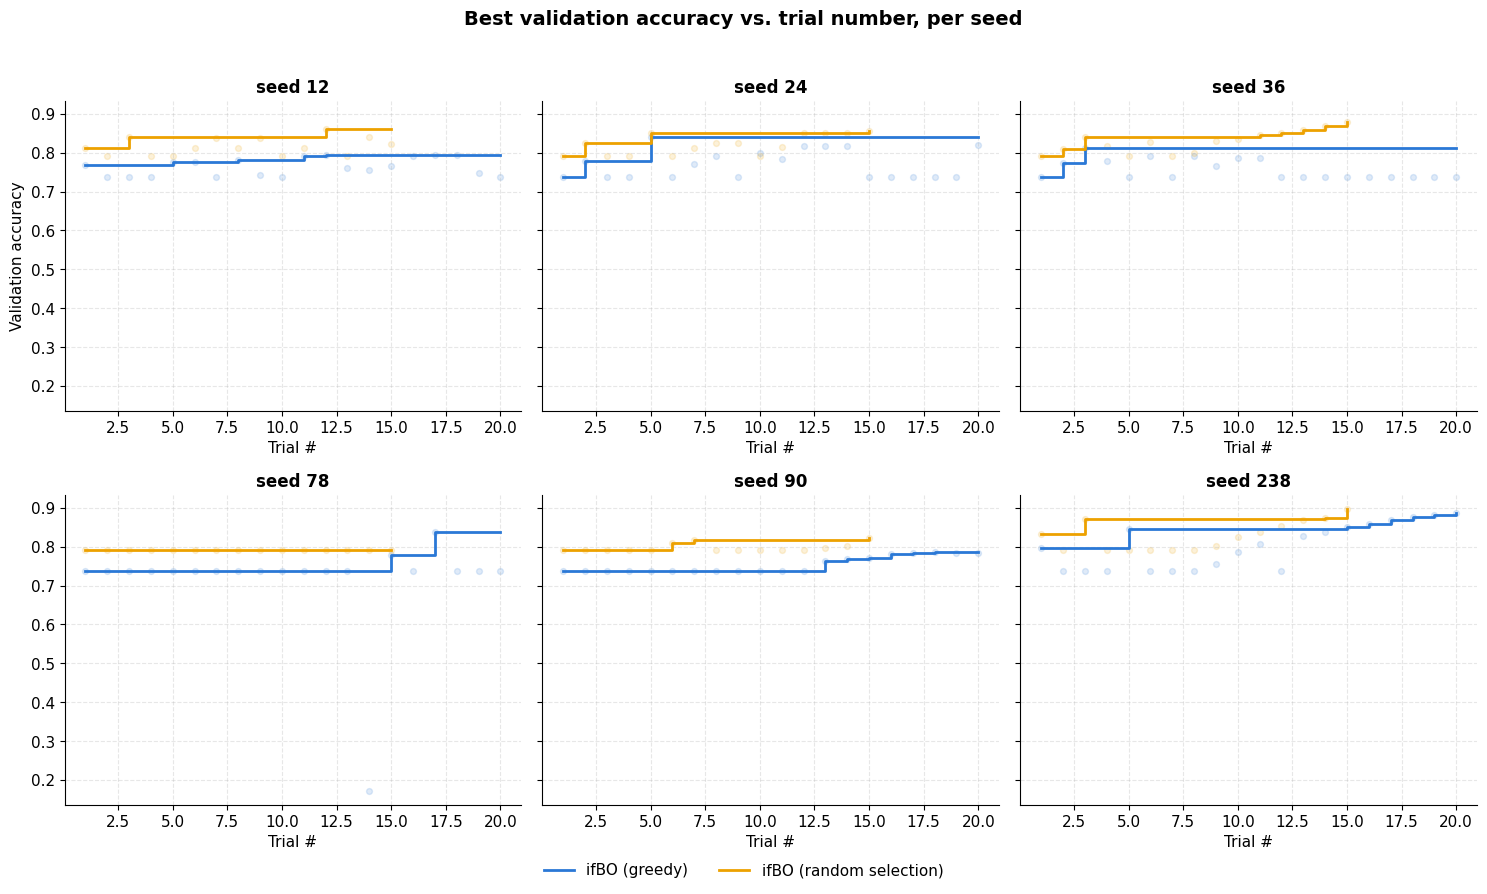

In [3]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("trialNo")
        if sub.empty:
            continue
        color = COLORS[variant_key]
        ax.scatter(
            sub["trialNo"], sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1
        )
        ax.step(
            sub["trialNo"],
            sub["best_val_accuracy_so_far"],
            where="post",
            color=color,
            linewidth=2.0,
            label=variant_label,
            zorder=2,
        )
    ax.set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Trial #")

axes[0].set_ylabel("Validation accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Best validation accuracy vs. trial number, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 2. Best validation accuracy vs. wallclock time, per seed

Same per-seed view as above, but the x-axis is actual search wallclock
time rather than trial count. Since a trial's duration depends on the
epoch budget it trained for (see section 9), a variant that runs cheaper
trials can look better here even if it needs more trials to get there.


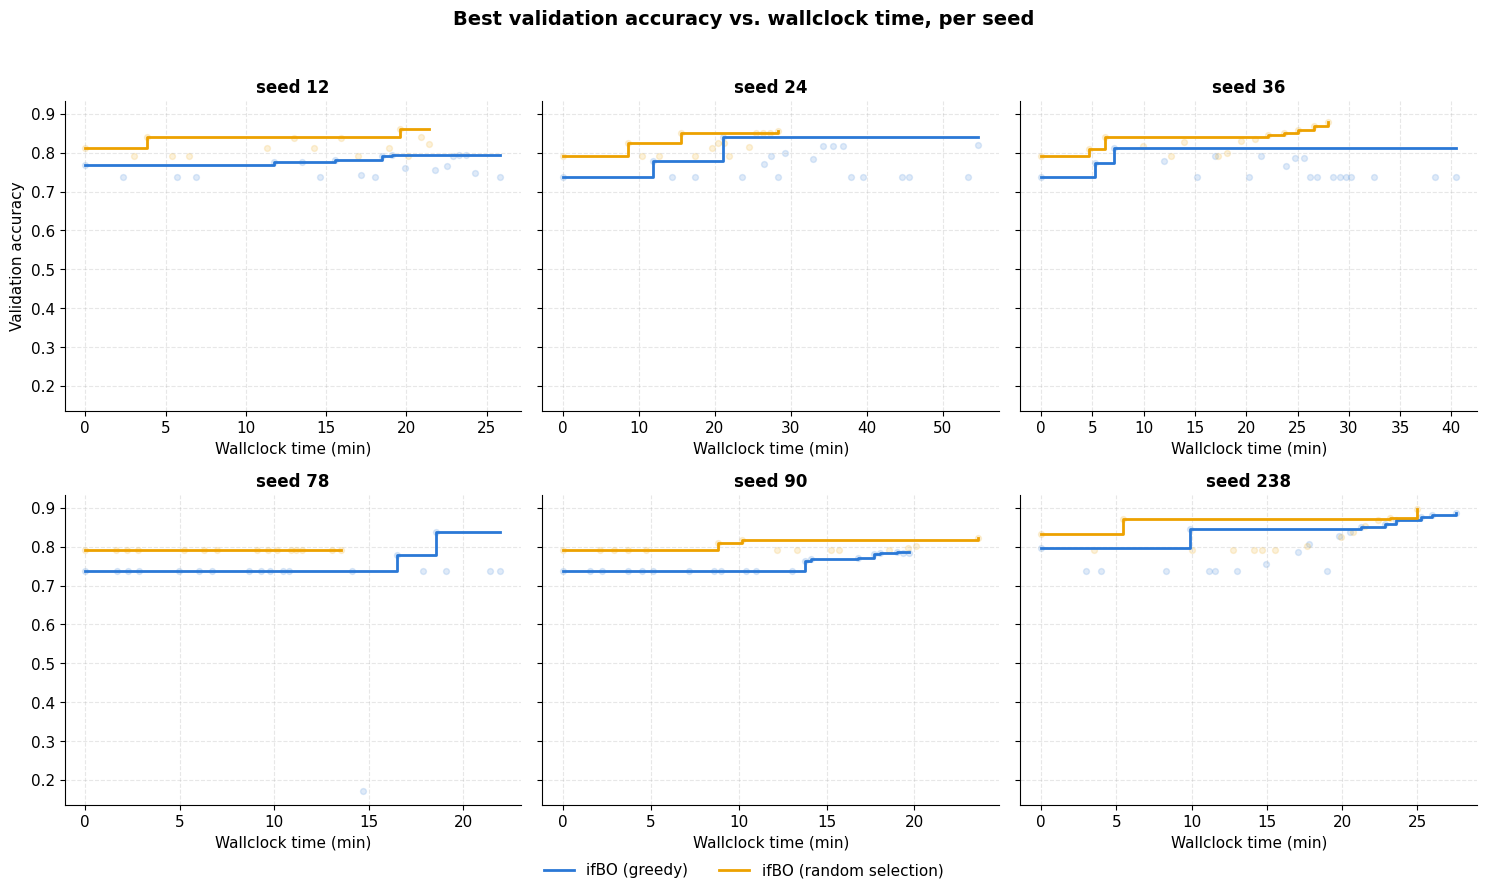

In [4]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("wallclock_s")
        if sub.empty:
            continue
        color = COLORS[variant_key]
        x_min = sub["wallclock_s"] / 60.0
        ax.scatter(x_min, sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1)
        ax.step(
            x_min,
            sub["best_val_accuracy_so_far"],
            where="post",
            color=color,
            linewidth=2.0,
            label=variant_label,
            zorder=2,
        )
    ax.set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Wallclock time (min)")

axes[0].set_ylabel("Validation accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Best validation accuracy vs. wallclock time, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 3. Aggregated convergence across seeds — trial number

Mean best-so-far validation accuracy at each trial number, averaged over
the 6 seeds per variant, with a ±1 std-dev band. This is the main
seed-sweep readout: it isolates the *systematic* effect of the candidate
selection rule from per-seed noise. Bands narrow near trial 1 (identical
first-trial config sampling) and widen as the search branches out.


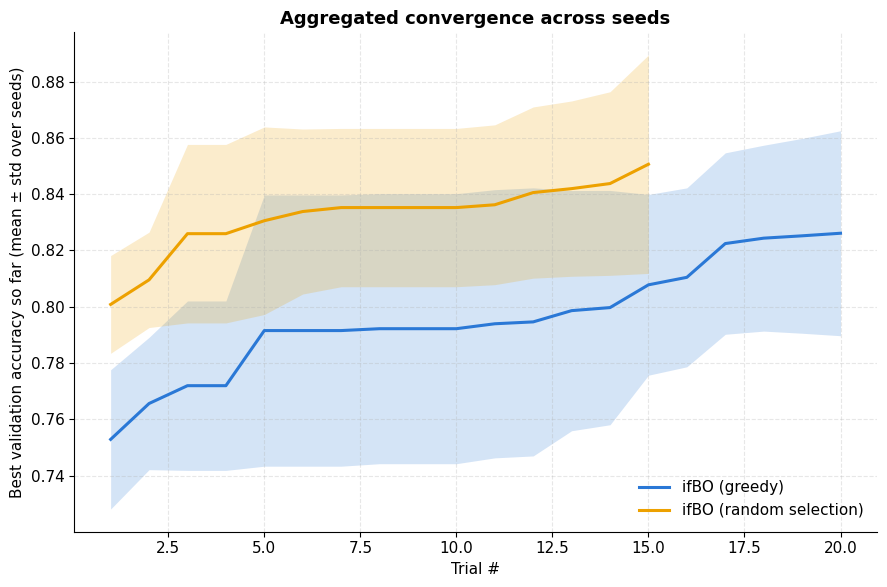

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for variant_key, variant_label in VARIANTS.items():
    sub = trials_df[trials_df["variant"] == variant_key]
    agg = sub.groupby("trialNo")["best_val_accuracy_so_far"].agg(["mean", "std", "count"])
    color = COLORS[variant_key]
    ax.plot(agg.index, agg["mean"], color=color, linewidth=2.2, label=variant_label)
    ax.fill_between(
        agg.index,
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        color=color,
        alpha=0.2,
        linewidth=0,
    )

ax.set_xlabel("Trial #")
ax.set_ylabel("Best validation accuracy so far (mean ± std over seeds)")
ax.set_title("Aggregated convergence across seeds", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 4. Aggregated convergence across seeds — wallclock time

Same idea as the trial-number aggregation above, but each seed's
best-so-far step function is resampled onto a common wallclock-time grid
first (holding a seed's incumbent constant once its search finishes),
then averaged. This is the fairest read of "how good is the incumbent
after N minutes of search," since it accounts for trials not all costing
the same amount of wallclock time.


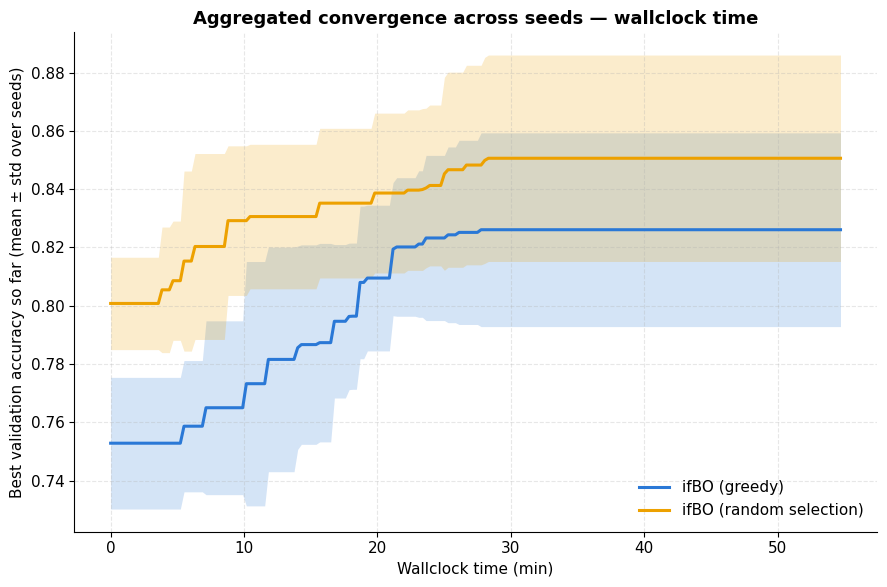

In [6]:
def best_so_far_at(seed: int, variant_key: str, t_grid: np.ndarray) -> np.ndarray:
    sub = trials_df[(trials_df["seed"] == seed) & (trials_df["variant"] == variant_key)].sort_values("wallclock_s")
    times = sub["wallclock_s"].to_numpy()
    values = sub["best_val_accuracy_so_far"].to_numpy()
    idx = np.searchsorted(times, t_grid, side="right") - 1
    result = np.full_like(t_grid, np.nan, dtype=float)
    valid = idx >= 0
    result[valid] = values[idx[valid]]
    return result


max_t = trials_df["wallclock_s"].max()
t_grid = np.linspace(0, max_t, 200)

fig, ax = plt.subplots(figsize=(9, 6))
for variant_key, variant_label in VARIANTS.items():
    curves = np.stack([best_so_far_at(seed, variant_key, t_grid) for seed in SEEDS])
    mean = np.nanmean(curves, axis=0)
    std = np.nanstd(curves, axis=0)
    color = COLORS[variant_key]
    ax.plot(t_grid / 60.0, mean, color=color, linewidth=2.2, label=variant_label)
    ax.fill_between(t_grid / 60.0, mean - std, mean + std, color=color, alpha=0.2, linewidth=0)

ax.set_xlabel("Wallclock time (min)")
ax.set_ylabel("Best validation accuracy so far (mean ± std over seeds)")
ax.set_title("Aggregated convergence across seeds — wallclock time", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 5. Final best accuracy per seed


In [7]:
final_acc = (
    trials_df.groupby(["seed", "variant"])["val_accuracy"]
    .max()
    .unstack("variant")[list(VARIANTS)]
)
final_acc.columns = final_acc.columns.map(VARIANTS)
final_acc


variant,ifBO (greedy),ifBO (random selection)
seed,,
12,0.7950,0.860744
24,0.8390,0.855942
36,0.8110,0.877951
78,0.8375,0.790316
90,0.7875,0.821529
238,0.8865,0.897159


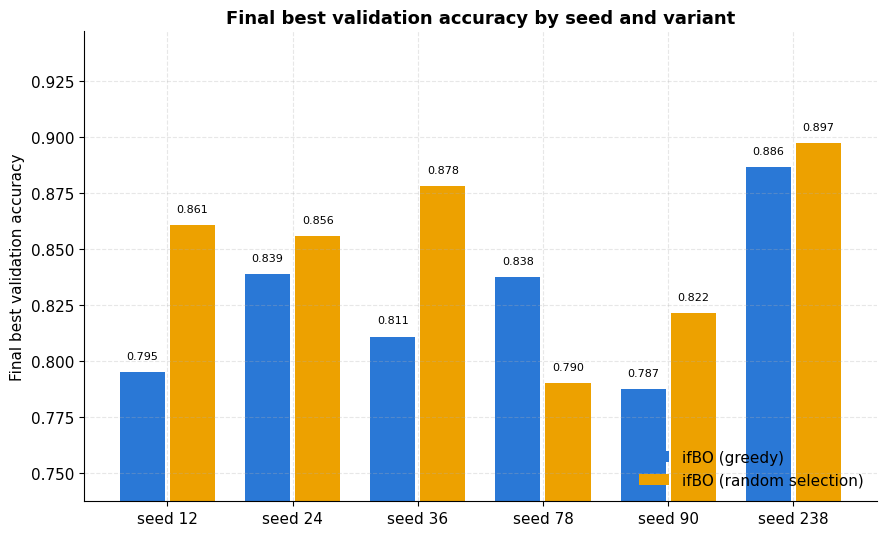

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
n_var = len(VARIANTS)
x = np.arange(len(final_acc.index))
width = 0.8 / n_var

for i, (variant_key, variant_label) in enumerate(VARIANTS.items()):
    vals = final_acc[variant_label]
    offset = x + i * width - 0.4 + width / 2
    ax.bar(offset, vals, width=width * 0.9, color=COLORS[variant_key], label=variant_label)
    for xi, v in zip(offset, vals):
        ax.text(xi, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"seed {s}" for s in final_acc.index])
ax.set_ylabel("Final best validation accuracy")
ax.set_ylim(final_acc.values.min() - 0.05, final_acc.values.max() + 0.05)
ax.set_title("Final best validation accuracy by seed and variant", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 6. Robustness across seeds

Distribution of each variant's *final* best accuracy across the 6 seeds.
A tighter, higher distribution means the candidate-selection rule finds a
strong incumbent reliably regardless of seed, not just on lucky draws.


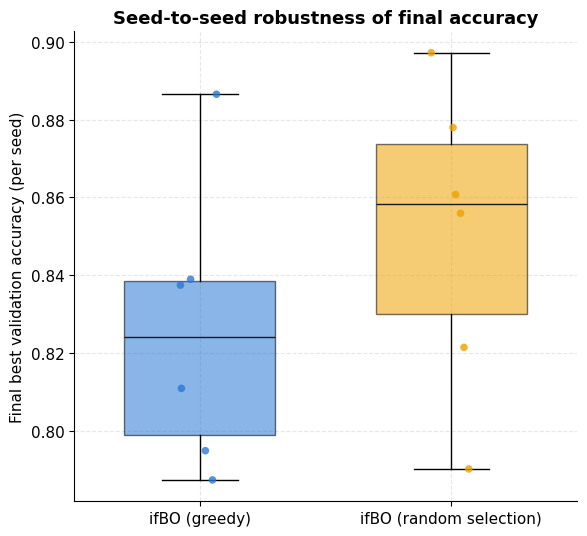

variant,ifBO (greedy),ifBO (random selection)
mean,0.826083,0.850607
std,0.036413,0.038798
min,0.787500,0.790316
max,0.886500,0.897159


In [9]:
fig, ax = plt.subplots(figsize=(6, 5.5))
rng = np.random.default_rng(0)
data = [final_acc[variant_label].values for variant_label in VARIANTS.values()]

bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
for patch, variant_key in zip(bp["boxes"], VARIANTS):
    patch.set_facecolor(COLORS[variant_key])
    patch.set_alpha(0.55)
for median in bp["medians"]:
    median.set_color("#1a1a19")

for i, variant_label in enumerate(VARIANTS.values(), start=1):
    pts = final_acc[variant_label].values
    jitter = rng.uniform(-0.08, 0.08, size=len(pts))
    ax.scatter(
        np.full(len(pts), i) + jitter, pts, color=COLORS[list(VARIANTS)[i - 1]],
        s=30, alpha=0.8, zorder=3, edgecolor="none",
    )

ax.set_xticks(range(1, len(VARIANTS) + 1))
ax.set_xticklabels(list(VARIANTS.values()))
ax.set_ylabel("Final best validation accuracy (per seed)")
ax.set_title("Seed-to-seed robustness of final accuracy", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

final_acc.agg(["mean", "std", "min", "max"]).rename(columns=lambda c: c)


## 7. Paired per-seed comparison

Since both variants were run on the *same* 6 seeds, we can pair them up
directly: each line below connects one seed's greedy result to its
random-selection result. A Wilcoxon signed-rank test on the paired
differences checks whether greedy's edge (or lack of one) is more than
noise across only 6 pairs -- treat the p-value as indicative, not
conclusive, given the small sample.


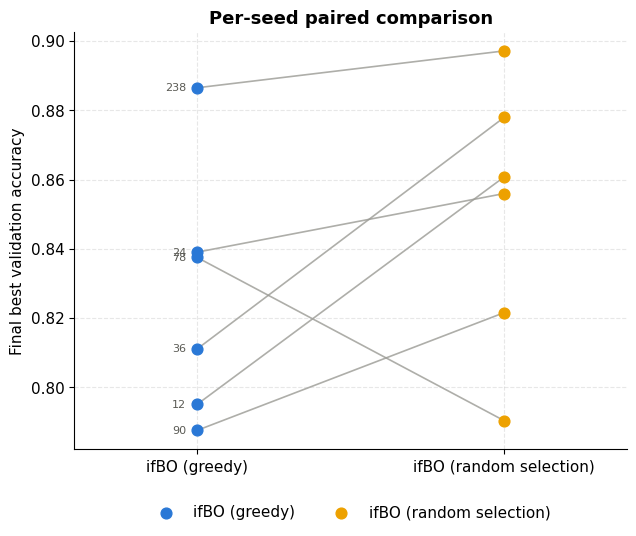

Mean (greedy - random) final accuracy: -0.0245 (std 0.0424)
Seeds where greedy wins: 1/6
Wilcoxon signed-rank test: statistic=4.00, p=0.2188


In [10]:
greedy_label, random_label = VARIANTS["ifbo-greedy"], VARIANTS["ifbo-random"]
paired = final_acc[[greedy_label, random_label]].dropna()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for seed, row in paired.iterrows():
    ax.plot(
        [0, 1], [row[greedy_label], row[random_label]],
        color="#9a9a94", linewidth=1.2, zorder=1, alpha=0.8,
    )
    ax.annotate(f"{seed}", (0, row[greedy_label]), textcoords="offset points",
                xytext=(-8, 0), ha="right", va="center", fontsize=8, color="#5a5a54")

ax.scatter(np.zeros(len(paired)), paired[greedy_label], color=COLORS["ifbo-greedy"], s=60, zorder=2, label=greedy_label)
ax.scatter(np.ones(len(paired)), paired[random_label], color=COLORS["ifbo-random"], s=60, zorder=2, label=random_label)

ax.set_xticks([0, 1])
ax.set_xticklabels([greedy_label, random_label])
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel("Final best validation accuracy")
ax.set_title("Per-seed paired comparison", fontsize=13, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
fig.tight_layout()
plt.show()

diff = paired[greedy_label] - paired[random_label]
wilcoxon_res = stats.wilcoxon(paired[greedy_label], paired[random_label])
print(f"Mean (greedy - random) final accuracy: {diff.mean():+.4f} (std {diff.std():.4f})")
print(f"Seeds where greedy wins: {(diff > 0).sum()}/{len(diff)}")
print(f"Wilcoxon signed-rank test: statistic={wilcoxon_res.statistic:.2f}, p={wilcoxon_res.pvalue:.4f}")


## 8. Search cost: trials run and wallclock time

ifBO (greedy) was configured to run more trials per seed (20 vs. 15) in
this sweep, so raw wallclock time isn't directly comparable to random
selection's -- shown here for completeness alongside trial counts, not as
a head-to-head speed comparison.


In [11]:
cost = trials_df.groupby(["seed", "variant"]).agg(
    n_trials=("trialNo", "max"), total_wallclock_min=("wallclock_s", "max")
)
cost["total_wallclock_min"] /= 60.0
cost = cost.unstack("variant")
cost.columns = cost.columns.set_levels(cost.columns.levels[1].map(VARIANTS), level=1)
cost


n_trials                         total_wallclock_min  \
variant ifBO (greedy) ifBO (random selection)       ifBO (greedy)   
seed                                                                
12                 20                      15           25.844246   
24                 20                      15           54.707247   
36                 20                      15           40.478962   
78                 20                      15           21.962930   
90                 20                      15           19.675774   
238                20                      15           27.580976   

                                 
variant ifBO (random selection)  
seed                             
12                    21.384732  
24                    28.256751  
36                    27.951862  
78                    13.529790  
90                    23.634004  
238                   25.003983

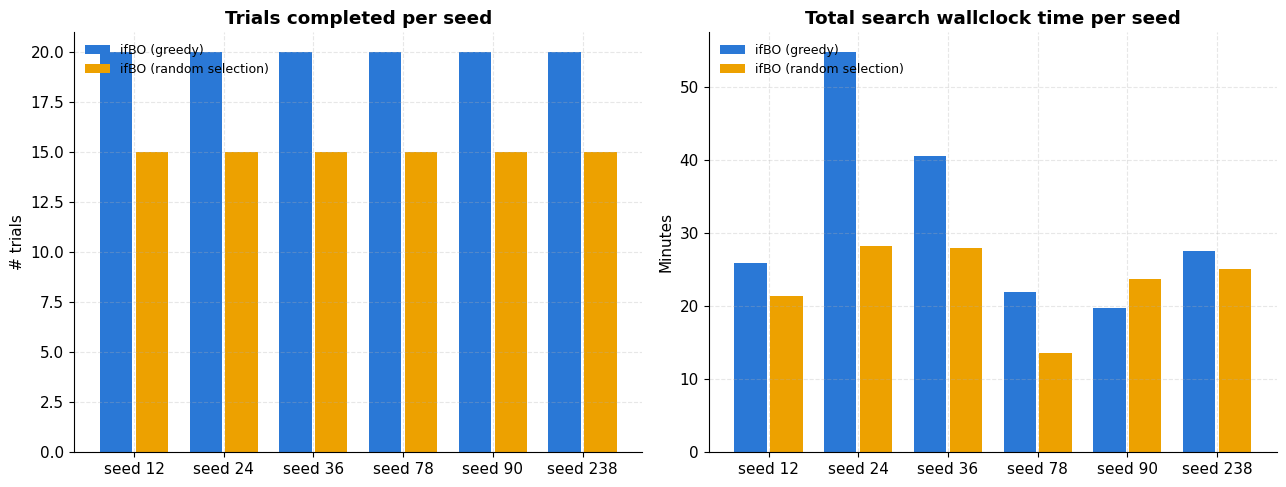

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(SEEDS))
width = 0.8 / len(VARIANTS)

for i, (variant_key, variant_label) in enumerate(VARIANTS.items()):
    offset = x + i * width - 0.4 + width / 2
    n_trials = cost[("n_trials", variant_label)]
    wallclock = cost[("total_wallclock_min", variant_label)]
    axes[0].bar(offset, n_trials, width=width * 0.9, color=COLORS[variant_key], label=variant_label)
    axes[1].bar(offset, wallclock, width=width * 0.9, color=COLORS[variant_key], label=variant_label)

axes[0].set_title("Trials completed per seed", fontweight="bold")
axes[0].set_ylabel("# trials")
axes[1].set_title("Total search wallclock time per seed", fontweight="bold")
axes[1].set_ylabel("Minutes")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"seed {s}" for s in SEEDS])
    ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()


## 9. Per-trial execution time: cost of an evaluation

All seeds pooled. Left: distribution of how long a single trial takes to
train, per variant. Right: trial cost vs. the epoch budget it trained for
-- since ifBO's freeze-thaw can resume a config from a prior checkpoint,
cost tracks the *incremental* epochs trained rather than the cumulative
budget shown on the x-axis, so expect a loose, not perfectly linear,
relationship.


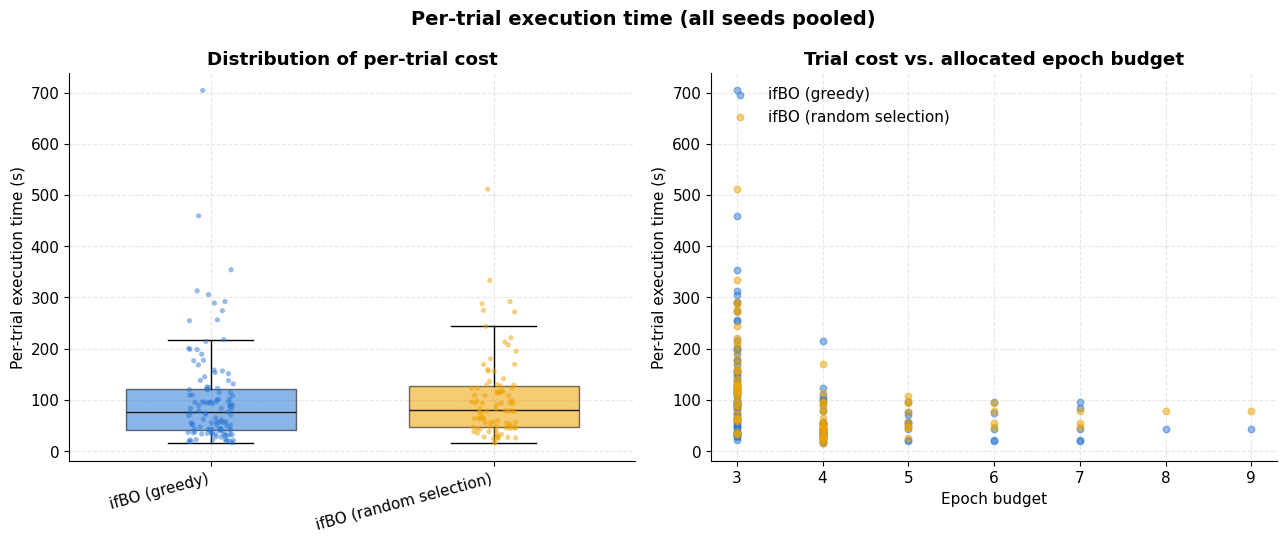

,mean,50%,std,max
variant_label,,,,
ifBO (greedy),101.931875,75.836795,96.985943,703.975101
ifBO (random selection),103.701794,80.980196,81.477972,511.432061


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
rng = np.random.default_rng(0)

data = [trials_df[trials_df["variant"] == v]["execution_time"].to_numpy() for v in VARIANTS]
bp = axes[0].boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
for patch, variant_key in zip(bp["boxes"], VARIANTS):
    patch.set_facecolor(COLORS[variant_key])
    patch.set_alpha(0.55)
for median in bp["medians"]:
    median.set_color("#1a1a19")

for i, variant_key in enumerate(VARIANTS, start=1):
    pts = trials_df[trials_df["variant"] == variant_key]["execution_time"].to_numpy()
    jitter = rng.uniform(-0.08, 0.08, size=len(pts))
    axes[0].scatter(
        np.full(len(pts), i) + jitter, pts, color=COLORS[variant_key], s=14, alpha=0.5, zorder=3, edgecolor="none"
    )

axes[0].set_xticks(range(1, len(VARIANTS) + 1))
axes[0].set_xticklabels(list(VARIANTS.values()), rotation=15, ha="right")
axes[0].set_ylabel("Per-trial execution time (s)")
axes[0].set_title("Distribution of per-trial cost", fontweight="bold")

for variant_key, variant_label in VARIANTS.items():
    sub = trials_df[trials_df["variant"] == variant_key]
    axes[1].scatter(sub["budget"], sub["execution_time"], color=COLORS[variant_key], alpha=0.5, s=22, label=variant_label)

axes[1].set_xlabel("Epoch budget")
axes[1].set_ylabel("Per-trial execution time (s)")
axes[1].set_title("Trial cost vs. allocated epoch budget", fontweight="bold")
axes[1].legend(loc="upper left", frameon=False)

fig.suptitle("Per-trial execution time (all seeds pooled)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

trials_df.groupby("variant_label")["execution_time"].describe()[["mean", "50%", "std", "max"]]


## 10. Fidelity (epoch budget) allocated per trial

Shows each variant's freeze-thaw behavior: how many epochs get allocated
to each successive trial as the search progresses.


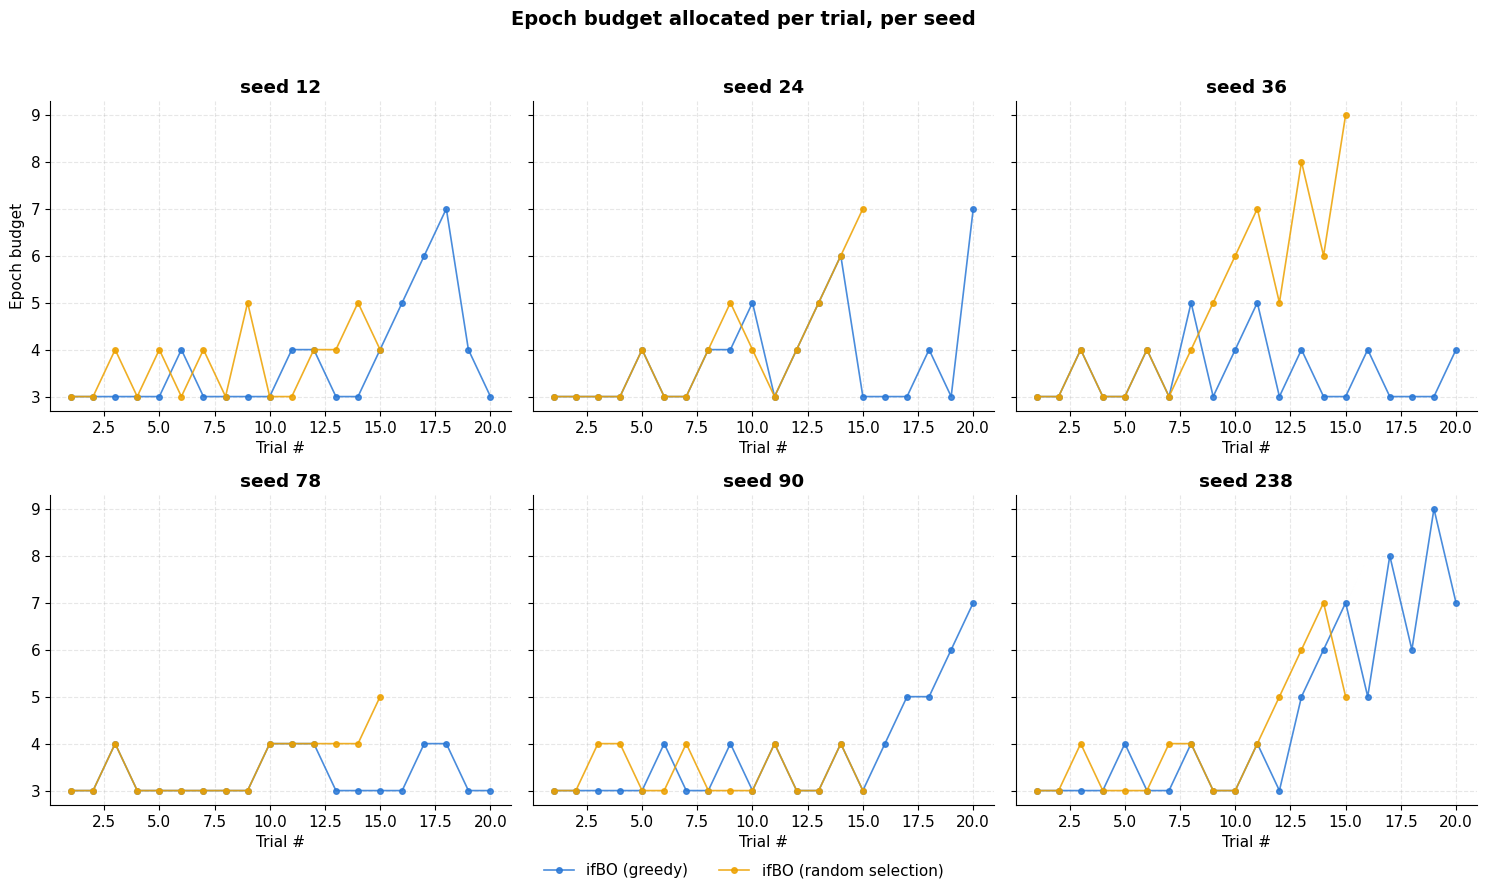

In [14]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("trialNo")
        if sub.empty:
            continue
        ax.plot(
            sub["trialNo"], sub["budget"], "o-", color=COLORS[variant_key],
            markersize=4, linewidth=1.2, alpha=0.85, label=variant_label,
        )
    ax.set_title(f"seed {seed}", fontweight="bold")
    ax.set_xlabel("Trial #")

axes[0].set_ylabel("Epoch budget")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Epoch budget allocated per trial, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 11. Training curve of each variant's best trial (across all seeds)


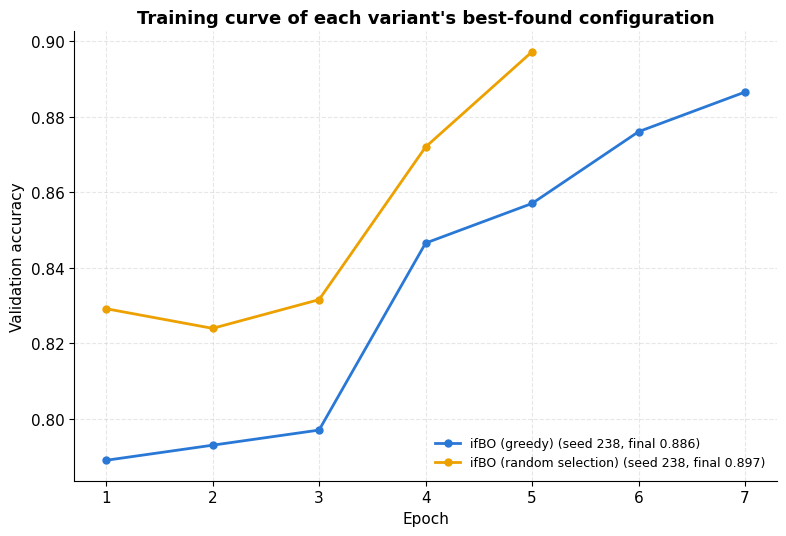

In [15]:
def best_trial_overall(variant_key: str) -> tuple[int, dict]:
    candidates = [
        (seed, t)
        for (v, seed), trials in raw_trials.items()
        if v == variant_key
        for t in trials
    ]
    seed, t = min(candidates, key=lambda st: st[1]["val_error"])
    return seed, t


fig, ax = plt.subplots(figsize=(8, 5.5))
for variant_key, variant_label in VARIANTS.items():
    seed, t = best_trial_overall(variant_key)
    epochs = [e["epoch"] for e in t["epoch_history"]]
    accs = [e["val_accuracy"] for e in t["epoch_history"]]
    ax.plot(
        epochs, accs, "o-", color=COLORS[variant_key], markersize=5, linewidth=2.0,
        label=f"{variant_label} (seed {seed}, final {1 - t['val_error']:.3f})",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy")
ax.set_title("Training curve of each variant's best-found configuration", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9, frameon=False)
fig.tight_layout()
plt.show()


## Summary


In [16]:
summary = final_acc.agg(["mean", "std", "min", "max"]).T
summary["mean_n_trials"] = cost["n_trials"].mean()
summary["mean_wallclock_min"] = cost["total_wallclock_min"].mean()
summary


,mean,std,min,max,mean_n_trials,mean_wallclock_min
variant,,,,,,
ifBO (greedy),0.826083,0.036413,0.787500,0.886500,20.0,31.708356
ifBO (random selection),0.850607,0.038798,0.790316,0.897159,15.0,23.293520
